# Homework 1 - Part 2: KNN Regressor
### Burak Kurucay - 210104004049
---

This section implements a KNN regressor from scratch using Manhattan distance with K=3.
The model is evaluated with 6-fold cross validation on the Bike Sharing hourly dataset.
Performance is reported using regression metrics, prediction visualizations, and runtime analysis.


## Code:


### Import the necessary modules


In [2]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sys.path.append(os.path.abspath("../src"))

from knn_regressor import KNNRegressor
from distance import manhattan_distance


### Load the dataset
Load the hourly bike sharing dataset and show the number of rows and columns.


In [3]:
data_path = os.path.abspath("../src/data/hour.csv")
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))


Dataset shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


### Sample the dataset
The original `hour.csv` dataset is large for a from-scratch KNN regressor, because each prediction compares a sample against many training instances. This makes the 6-fold cross validation take a long time. To keep the notebook practical while still preserving the overall target distribution, sample 600 rows using a fixed random state. The sampling is stratified by binned `cnt` values, so low, medium, and high demand levels remain represented in the smaller dataset.


In [4]:
df["cnt_bin"] = pd.qcut(df["cnt"], q=10, duplicates="drop")

df, _ = train_test_split(
    df,
    train_size=3000,
    random_state=42,
    stratify=df["cnt_bin"]
)

df = df.drop(columns=["cnt_bin"]).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)


Sampled dataset shape: (3000, 17)


### Prepare the dataset
Use `cnt` as the regression target. Exclude `casual` and `registered` to avoid target leakage, and drop `instant` and `dteday` because they are identifiers/date strings.


In [5]:
feature_columns = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed"
]

target_column = "cnt"

X = df[feature_columns].to_numpy()
y = df[target_column].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3000, 12)
y shape: (3000,)


### Monitor the data
Just to see the dataset loaded.


In [6]:
df[feature_columns + [target_column]].head()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,3,0,8,19,0,3,1,1,0.74,0.6818,0.55,0.2985,440
1,2,1,5,19,0,3,1,3,0.50,0.4848,0.77,0.3582,98
2,1,0,3,17,0,6,0,1,0.46,0.4545,0.44,0.3284,213
3,1,1,3,0,0,0,0,1,0.46,0.4545,0.88,0.1940,107
4,3,1,7,2,0,3,1,1,0.64,0.5758,0.89,0.0000,5


### Train By 6-Fold Cross Validation


In [7]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)

fold_results = []
overall_start_time = time.time()

for fold_idx, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = KNNRegressor(k=3, distance_func=manhattan_distance)

    fold_start_time = time.time()

    # Check if the model is fitting correctly
    try:
        model.fit(X_train, y_train)
    except Exception as e:
        print(f"Error during model fitting in fold {fold_idx}: {e}")
        continue

    # Check if predictions are being made correctly
    try:
        train_predictions = np.array(model.predict(X_train))
        test_predictions = np.array(model.predict(X_test))
    except Exception as e:
        print(f"Error during prediction in fold {fold_idx}: {e}")
        continue

    fold_end_time = time.time()

    # Calculate metrics and handle potential errors
    try:
        train_mae = mean_absolute_error(y_train, train_predictions)
        test_mae = mean_absolute_error(y_test, test_predictions)
        train_rmse = np.sqrt(np.mean((y_train - train_predictions) ** 2))
        test_rmse = np.sqrt(np.mean((y_test - test_predictions) ** 2))
        train_r2 = r2_score(y_train, train_predictions)
        test_r2 = r2_score(y_test, test_predictions)

        fold_results.append({
            "fold": fold_idx,
            "train_mae": train_mae,
            "test_mae": test_mae,
            "train_rmse": train_rmse,
            "test_rmse": test_rmse,
            "train_r2": train_r2,
            "test_r2": test_r2,
            "y_test": y_test,
            "test_predictions": test_predictions,
            "runtime_seconds": fold_end_time - fold_start_time
        })
    except Exception as e:
        print(f"Error during metric calculation in fold {fold_idx}: {e}")
        continue

overall_end_time = time.time()
mean_runtime = np.mean([r["runtime_seconds"] for r in fold_results])
total_runtime = overall_end_time - overall_start_time


## Results:


### Prediction Overview


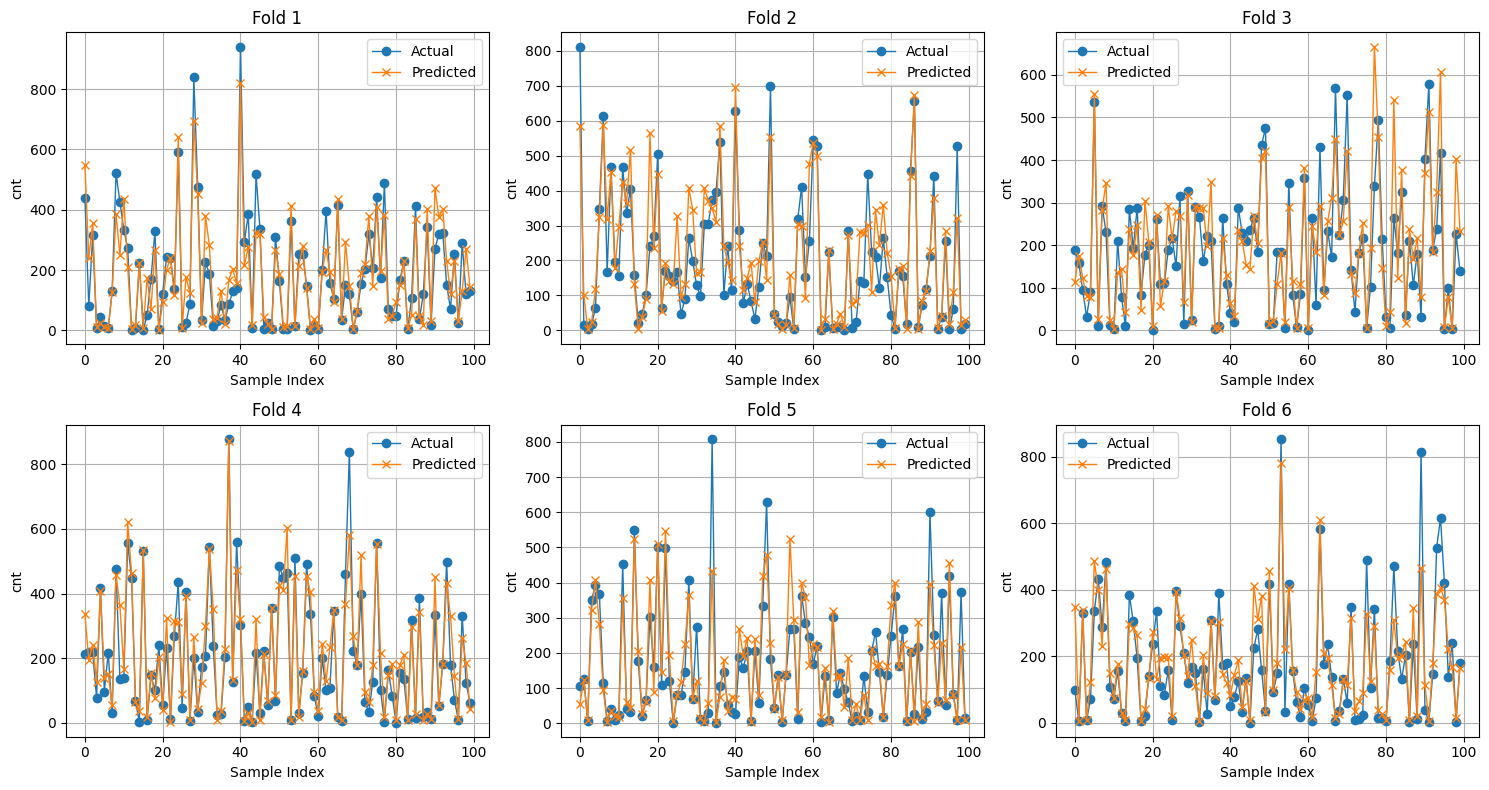

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax = axes[i]
    y_true = result["y_test"]
    y_pred = result["test_predictions"]

    sample_size = min(100, len(y_true))
    ax.plot(range(sample_size), y_true[:sample_size], marker='o', linewidth=1, label="Actual")
    ax.plot(range(sample_size), y_pred[:sample_size], marker='x', linewidth=1, label="Predicted")
    ax.set_title(f"Fold {result['fold']}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("cnt")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


### Regression Metrics


,Fold,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,1,34.0137,52.0160,53.5273,81.2742,0.9125,0.8115
1,2,35.3959,48.9253,55.7865,76.6497,0.9058,0.8259
2,3,34.4745,51.0133,54.3072,77.4885,0.9118,0.8101
3,4,35.0239,47.3333,54.4663,74.1518,0.9104,0.8350
4,5,35.1789,46.9173,55.7624,72.3644,0.9051,0.8508
5,6,35.3661,49.0100,55.5602,74.8987,0.9086,0.8119


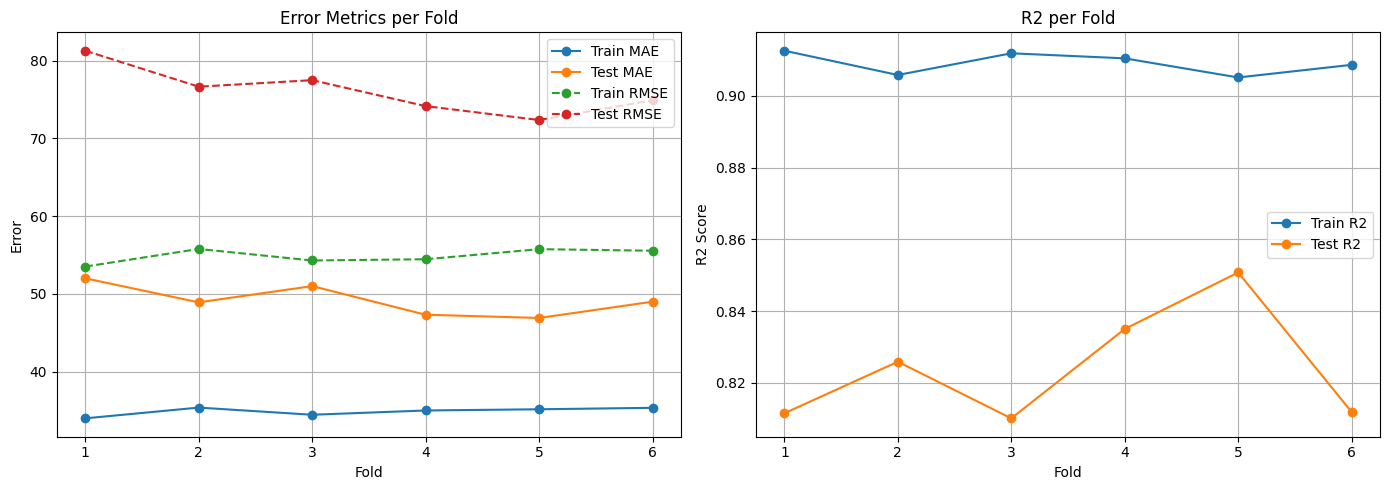

,Metric,Value
0,Mean Train MAE,34.9088
1,Mean Test MAE,49.2025
2,Mean Train RMSE,54.9016
3,Mean Test RMSE,76.1379
4,Mean Train R2,0.9090
5,Mean Test R2,0.8242


In [9]:
metric_rows = []

for result in fold_results:
    metric_rows.append({
        "Fold": result["fold"],
        "Train MAE": result["train_mae"],
        "Test MAE": result["test_mae"],
        "Train RMSE": result["train_rmse"],
        "Test RMSE": result["test_rmse"],
        "Train R2": result["train_r2"],
        "Test R2": result["test_r2"]
    })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].round(4)
display(df_metrics)

folds = [r["fold"] for r in fold_results]
train_maes = [r["train_mae"] for r in fold_results]
test_maes = [r["test_mae"] for r in fold_results]
train_rmses = [r["train_rmse"] for r in fold_results]
test_rmses = [r["test_rmse"] for r in fold_results]
train_r2s = [r["train_r2"] for r in fold_results]
test_r2s = [r["test_r2"] for r in fold_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(folds, train_maes, marker='o', label="Train MAE")
axes[0].plot(folds, test_maes, marker='o', label="Test MAE")
axes[0].plot(folds, train_rmses, marker='o', linestyle='--', label="Train RMSE")
axes[0].plot(folds, test_rmses, marker='o', linestyle='--', label="Test RMSE")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error")
axes[0].set_title("Error Metrics per Fold")
axes[0].set_xticks(folds)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(folds, train_r2s, marker='o', label="Train R2")
axes[1].plot(folds, test_r2s, marker='o', label="Test R2")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R2 Score")
axes[1].set_title("R2 per Fold")
axes[1].set_xticks(folds)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

df_metrics_summary = pd.DataFrame({
    "Metric": [
        "Mean Train MAE",
        "Mean Test MAE",
        "Mean Train RMSE",
        "Mean Test RMSE",
        "Mean Train R2",
        "Mean Test R2"
    ],
    "Value": [
        df_metrics["Train MAE"].mean(),
        df_metrics["Test MAE"].mean(),
        df_metrics["Train RMSE"].mean(),
        df_metrics["Test RMSE"].mean(),
        df_metrics["Train R2"].mean(),
        df_metrics["Test R2"].mean()
    ]
})

df_metrics_summary["Value"] = df_metrics_summary["Value"].round(4)
display(df_metrics_summary)


### Runtime Performance
The runtime of the KNN regressor was measured for each fold during the 6-fold cross validation process. <br>
Both per-fold runtimes and the total cross-validation runtime are reported below.


In [10]:
runtime_rows = []

for result in fold_results:
    runtime_rows.append({
        "Fold": result["fold"],
        "Runtime (seconds)": result["runtime_seconds"]
    })

df_runtime = pd.DataFrame(runtime_rows)
df_runtime["Runtime (seconds)"] = df_runtime["Runtime (seconds)"].round(4)
display(df_runtime)

df_runtime_summary = pd.DataFrame({
    "Metric": [
        "Average runtime per fold",
        "Total 6-fold CV runtime"
    ],
    "Runtime (seconds)": [
        mean_runtime,
        total_runtime
    ]
})

df_runtime_summary["Runtime (seconds)"] = df_runtime_summary["Runtime (seconds)"].round(4)
display(df_runtime_summary)


,Fold,Runtime (seconds)
0,1,16.0619
1,2,16.1093
2,3,16.4496
3,4,16.1703
4,5,16.1531
5,6,16.0151


,Metric,Runtime (seconds)
0,Average runtime per fold,16.1599
1,Total 6-fold CV runtime,96.9649


### Selected Fold Performance Results
Select the fold whose test RMSE is closest to the mean test RMSE across all folds

In [11]:
mean_test_rmse = np.mean([r["test_rmse"] for r in fold_results])

selected_fold = min(
    fold_results,
    key=lambda r: abs(r["test_rmse"] - mean_test_rmse)
)


,Metric,Value
0,Train MAE,35.3959
1,Test MAE,48.9253
2,Train RMSE,55.7865
3,Test RMSE,76.6497
4,Train R2,0.9058
5,Test R2,0.8259


,Actual,Predicted
0,812,586.0000
1,16,102.6667
2,4,3.0000
3,18,23.3333
4,63,118.6667
5,346,325.3333
6,612,588.6667
7,166,318.3333
8,466,452.0000
9,195,178.6667


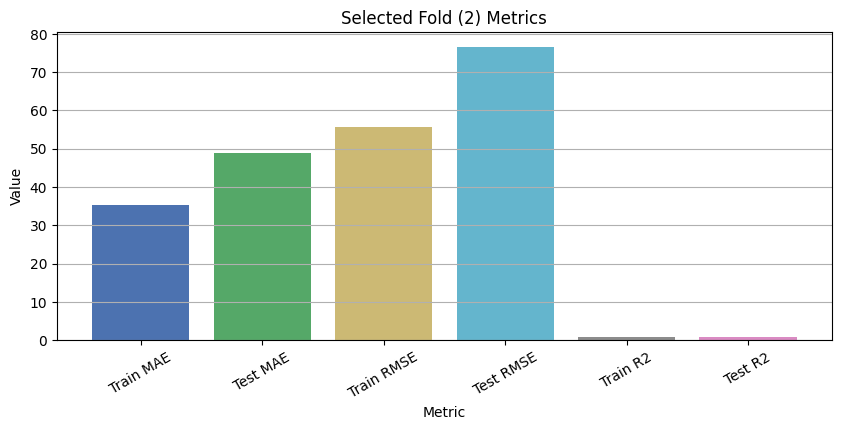

,Actual,Predicted
0,812,586.0000
1,16,102.6667
2,4,3.0000
3,18,23.3333
4,63,118.6667
5,346,325.3333
6,612,588.6667
7,166,318.3333
8,466,452.0000
9,195,178.6667


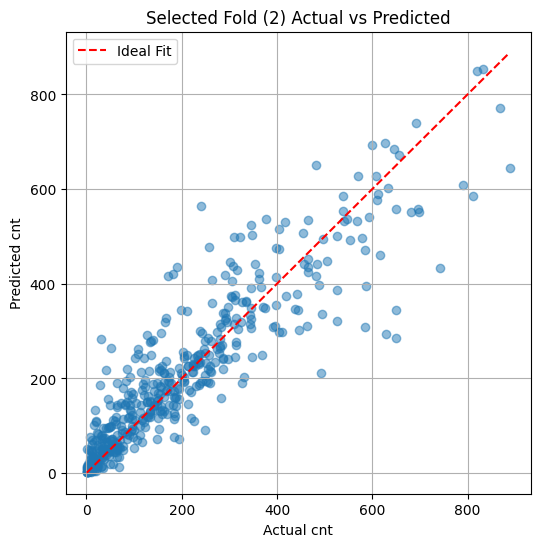

In [12]:
df_selected_performance = pd.DataFrame({
    "Metric": ["Train MAE", "Test MAE", "Train RMSE", "Test RMSE", "Train R2", "Test R2"],
    "Value": [
        selected_fold["train_mae"],
        selected_fold["test_mae"],
        selected_fold["train_rmse"],
        selected_fold["test_rmse"],
        selected_fold["train_r2"],
        selected_fold["test_r2"]
    ]
})

df_selected_performance["Value"] = df_selected_performance["Value"].round(4)
display(df_selected_performance)

selected_predictions_df = pd.DataFrame({
    "Actual": selected_fold["y_test"][:20],
    "Predicted": np.round(selected_fold["test_predictions"][:20], 4)
})

display(selected_predictions_df)

plt.figure(figsize=(10, 4))
plt.bar(
    df_selected_performance["Metric"],
    df_selected_performance["Value"],
    color=["#4C72B0", "#55A868", "#CCB974", "#64B5CD", "#8C8C8C", "#DA8BC3"]
)
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title(f"Selected Fold ({selected_fold['fold']}) Metrics")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

selected_predictions_df = pd.DataFrame({
    "Actual": selected_fold["y_test"][:20],
    "Predicted": np.round(selected_fold["test_predictions"][:20], 4)
})

display(selected_predictions_df)

plt.figure(figsize=(6, 6))
plt.scatter(selected_fold["y_test"], selected_fold["test_predictions"], alpha=0.5)
min_val = min(selected_fold["y_test"].min(), selected_fold["test_predictions"].min())
max_val = max(selected_fold["y_test"].max(), selected_fold["test_predictions"].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label="Ideal Fit")
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title(f"Selected Fold ({selected_fold['fold']}) Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


## Comments:
- The KNN regressor achieves strong overall accuracy, as reflected by the relatively low test MAE and the comparatively high test R2 values across folds. At the same time, test RMSE stays clearly above test MAE, which suggests that the model still produces a number of larger individual errors.
- This MAE-RMSE gap is consistent with the nature of KNN. Since predictions are based on nearby observations, performance can deteriorate in sparse or noisy regions where the selected neighbors are less representative of the true local pattern.
- The prediction overview and the selected-fold scatter plot indicate that deviations become more visible for larger target values. This is a plausible outcome for KNN, because extreme demand levels are usually less frequent and may not have sufficiently similar neighbors in the training set.
- The train and test metrics remain reasonably close, so the model does not show a severe sign of overfitting. However, the fold-to-fold variation suggests that the method is still somewhat dependent on the local sample distribution of each split.
- The runtime is much higher than that of the SVM-based regressor. This is expected because KNN is a lazy learning method, and a substantial part of the computational cost is transferred to prediction time through repeated distance calculations.
